In [1]:
import pandas as pd
import numpy as np
import joblib

### wczytywanie danych dla modelu Supervised Learning
df = joblib.load('df_with_all_clusters.joblib')

umap_embeddings = np.load('umap_embeddings_10d.npy')

print("Obiekty wczytane.")

### definicja Zmiennych 
#### cechy (features) na których będziemy trenować model
X = umap_embeddings

#### cel (target)
y = df['nmf_topic']

print(f"Kształt danych X (cechy): {X.shape}")

print(f"Kształt danych y (cel): {y.shape}")

Obiekty wczytane.
Kształt danych X (cechy): (850367, 10)
Kształt danych y (cel): (850367,)


In [2]:
from sklearn.model_selection import train_test_split

### podział na zbiór treningowy i testowy
###### dane w proporcji 80% na trening, 20% na test
###### random_state=42 - podział będzie zawsze taki sam
###### stratify=y - tutaj ważny parametr -> w zbiorze treningowym i testowym musi być taki sam % udział każdej z 20 klas / tematów
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Rozmiar X_train: {X_train.shape}")
print(f"Rozmiar X_test: {X_test.shape}")

Rozmiar X_train: (680293, 10)
Rozmiar X_test: (170074, 10)


In [3]:
### adding decision boundary visualisation function

from sklearn.decomposition import PCA
from sklearn.base import clone
from numpy import where, arange, meshgrid, hstack, unique
import matplotlib.pyplot as plt

def visualize_decision_boundary_multiclass(X_data, y_data, trained_classifier, title="Granica decyzyjna modelu"):
    """
    Wizualizuje granicę decyzyjną klasyfikatora dla wielu klas 
    po zredukowaniu danych do 2 wymiarów za pomocą PCA.

    Argumenty:
    - X_data: Oryginalne, przetworzone dane (np. X_train_prepared).
    - y_data: Etykiety (np. y_train lub y_test).
    - trained_classifier: Model, którego typ chcemy zwizualizować (np. Random Forest itd.).
    - title: Tytuł wykresu.
    """
    ## redukcja wymiarów danych do 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_data)

    ## klonowanie modelu z jego hiperparametrami aby zachować wszystkie ustawienia (np. n_estimators, max_depth, C, etc.)
    model_2d = clone(trained_classifier)
    model_2d.fit(X_pca, y_data)

    ## tworzenie siatki
    min1, max1 = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    min2, max2 = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    x1grid = arange(min1, max1, 0.1)
    x2grid = arange(min2, max2, 0.1)
    xx, yy = meshgrid(x1grid, x2grid)
    grid = hstack((xx.flatten().reshape(-1,1), yy.flatten().reshape(-1,1)))

    ## predykcja i rysowanie tła
    yhat = model_2d.predict(grid)
    zz = yhat.reshape(xx.shape)
    
    plt.figure(figsize=(16, 16))
    ## ta sama paleta co dla punktów, aby tło pasowało kolorami
    unique_classes = unique(y_data)
    cmap_background = plt.get_cmap('viridis', len(unique_classes))
    plt.contourf(xx, yy, zz, cmap=cmap_background, alpha=0.3)

    ## dynamiczne rysowanie punktów dla wielu klas
    cmap_points = plt.get_cmap('viridis', len(unique_classes))
    for i, class_value in enumerate(unique_classes):
        row_ix = where(y_data == class_value)
        plt.scatter(X_pca[row_ix, 0], X_pca[row_ix, 1],
                    color=cmap_points(i),
                    label=f'Klasa {class_value}',
                    alpha=0.7)

    plt.title(title, fontsize=15)
    plt.xlabel("Główna składowa 1 (PC1)", fontsize=12)
    plt.ylabel("Główna składowa 2 (PC2)", fontsize=12)
    plt.legend()
    plt.show()

In [4]:
### klasa z funkcjami do ewaluacji modeli i kalkulacji / porównania metryk

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
import seaborn as sns
from IPython.display import display

class ModelEvaluator:
    """
    Klasa do kompleksowej oceny i wizualizacji modeli klasyfikacyjnych dla problemu wieloklasowego.
    Przechowuje wyniki dla wielu modeli i pozwala na ich porównanie.
    """
    def __init__(self):
        self.results = {}
        self.metrics_summary = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision_weighted', 
                                                     'Recall_weighted', 'F1_score_weighted', 'AUC_weighted'])

    def evaluate(self, model, model_name, X_train, y_train, X_test, y_test):
        """
        Ocenia już wytrenowany model i generuje raport z metrykami i wizualizacjami.
        """
        print(f"{'='*30}\nOcena modelu: {model_name}\n{'='*30}")

        #### predykcje na zbiorze testowym
        predictions = model.predict(X_test)
        
        #### sprawdzenie czy model ma predict_proba, aby uniknąć błędów
        if hasattr(model, "predict_proba"):
            ##### pobieranie pełnej macierzy prawdopodobieństw (nie tylko dla jednej klasy)
            predictions_proba = model.predict_proba(X_test)
            ##### obliczenie AUC dla wielu klas
            auc = roc_auc_score(y_test, predictions_proba, multi_class='ovr', average='weighted')
        else:
            predictions_proba = None
            auc = np.nan ###### AUC nie jest dostępne

        #### zapis modelu do późniejszej analizy
        self.results[model_name] = {'model': model}
        
        #### METRYKI I WIZUALIZACJE
        print("--- Raport Klasyfikacji ---")
        print(classification_report(y_test, predictions, zero_division=0))
        
        print("\n--- Macierz Omyłek ---")
        cm = confusion_matrix(y_test, predictions)
        plt.figure(figsize=(14, 12))
        ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')
        ax.set_title(f'Macierz Omyłek dla: {model_name}\n')
        ax.set_xlabel('\nPredykcja')
        ax.set_ylabel('Rzeczywista wartość')
        plt.show()

        #### obliczenie metryk dla wielu klas (używając uśredniania 'weighted')
        accuracy = accuracy_score(y_test, predictions)
        #### 'weighted' - liczy metryki dla każdej klasy i uśrednia je, ważąc liczbą próbek w każdej klasie
        precision = precision_score(y_test, predictions, average='weighted', zero_division=0)
        recall = recall_score(y_test, predictions, average='weighted', zero_division=0)
        f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
        
        new_row = pd.DataFrame([{'Model': model_name, 'Accuracy': accuracy, 'Precision_weighted': precision, 
                                 'Recall_weighted': recall, 'F1_score_weighted': f1, 'AUC_weighted': auc}])
        self.metrics_summary = pd.concat([self.metrics_summary, new_row], ignore_index=True)

        ### WIZUALIZACJA GRANIC DECYZYJNYCH
        print("\n--- Wizualizacje Granic Decyzyjnych ---")

        ## wizualizacja na danych treningowych
        print("\n[Wizualizacja 1/3] Granica decyzyjna na danych treningowych...")
        try:
            visualize_decision_boundary_multiclass(X_train, y_train, model,
                title=f"Granica decyzyjna (dane treningowe) - {model_name}")
        except Exception as e:
            print(f"Nie udało się wygenerować wizualizacji. Błąd: {e}")

        ## wizualizacja na danych testowych z prawdziwymi etykietami
        print("\n[Wizualizacja 2/3] Granica decyzyjna vs. Rzeczywiste klasy (dane testowe)...")
        try:
            visualize_decision_boundary_multiclass(X_test, y_test, model,
                title=f"Granica decyzyjna vs. Rzeczywiste klasy - {model_name}")
        except Exception as e:
            print(f"Nie udało się wygenerować wizualizacji. Błąd: {e}")

        ## wizualizacja na danych testowych z predykcjami
        print("\n[Wizualizacja 3/3] Granica decyzyjna vs. Predykcje (dane testowe)...")
        try:
            # Tworzymy serię z predykcjami, zachowując indeks ze zbioru testowego
            y_pred_series = pd.Series(predictions, index=y_test.index)
            visualize_decision_boundary_multiclass(X_test, y_pred_series, model,
                title=f"Granica decyzyjna vs. Predykcje - {model_name}")
        except Exception as e:
            print(f"Nie udało się wygenerować wizualizacji. Błąd: {e}")

    def display_summary(self, sort_by='F1_score_weighted'):
        """
        Wyświetla tabelaryczne podsumowanie metryk dla wszystkich ocenionych modeli.
        """
        print(f"\n{'='*30}\nPodsumowanie Metryk Modeli\n{'='*30}")
        if self.metrics_summary.empty:
            print("Brak ocenionych modeli do wyświetlenia.")
        else:
            display(self.metrics_summary.sort_values(by=sort_by, ascending=False).reset_index(drop=True))

In [5]:
### wczytaj wcześniej zapisany obiekt evaluator
evaluator = joblib.load('evaluator.joblib')
print(f"Obiekt ewaluatora został wczytany")

Obiekt ewaluatora został wczytany


Current tracking URI: file:///O:/Projects/covid19/mlruns
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5; 1/30] START boosting_type=gbdt, colsample_bytree=0.7, learning_rate=0.01, max_depth=-1, min_child_samples=50, n_estimators=1000, num_leaves=31, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 544234, number of used features: 10
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (6.23 MB) transferred to GPU in 0.004138 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -2.995761
[LightGBM] [Info] Start training from sc

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV 1/5; 1/30] END boosting_type=gbdt, colsample_bytree=0.7, learning_rate=0.01, max_depth=-1, min_child_samples=50, n_estimators=1000, num_leaves=31, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9;, score=0.495 total time= 2.7min
[CV 2/5; 1/30] START boosting_type=gbdt, colsample_bytree=0.7, learning_rate=0.01, max_depth=-1, min_child_samples=50, n_estimators=1000, num_leaves=31, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 544234, number of used features: 10
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (6.23 MB) transferred to GPU in 0.003699 secs. 0 sparse

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV 2/5; 1/30] END boosting_type=gbdt, colsample_bytree=0.7, learning_rate=0.01, max_depth=-1, min_child_samples=50, n_estimators=1000, num_leaves=31, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9;, score=0.493 total time= 2.5min
[CV 3/5; 1/30] START boosting_type=gbdt, colsample_bytree=0.7, learning_rate=0.01, max_depth=-1, min_child_samples=50, n_estimators=1000, num_leaves=31, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 544234, number of used features: 10
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (6.23 MB) transferred to GPU in 0.003963 secs. 0 sparse

...

[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (7.79 MB) transferred to GPU in 0.004466 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995

2025/10/11 11:58:47 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 2063c4126bdb49aea14db04acf4b3292. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'colsample_bytree\' was already logged with value=\'0.7\' for run ID=\'2063c4126bdb49aea14db04acf4b3292\'. Attempted logging new value \'0.8\'.")]')]
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Najlepszy model LightGBM-gbdt został zapisany.
Ocena modelu: LightGBM (gbdt) - best estimator


O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Raport Klasyfikacji ---
              precision    recall  f1-score   support

           0       0.29      0.42      0.34      6531
           1       0.72      0.55      0.62     23719
           2       0.51      0.47      0.49      7000
           3       0.54      0.27      0.36     15234
           4       0.75      0.85      0.80      5970
           5       0.40      0.52      0.45      6203
           6       0.68      0.81      0.74      6303
           7       0.43      0.61      0.50      6919
           8       0.67      0.69      0.68     11550
           9       0.43      0.45      0.44      7371
          10       0.52      0.61      0.56      4445
          11       0.68      0.69      0.69      3687
          12       0.47      0.55      0.51      5182
          13       0.56      0.62      0.59      6346
          14       0.39      0.45      0.42      6769
          15       0.41      0.40      0.40      7238
          16       0.49      0.41      0.44     11994

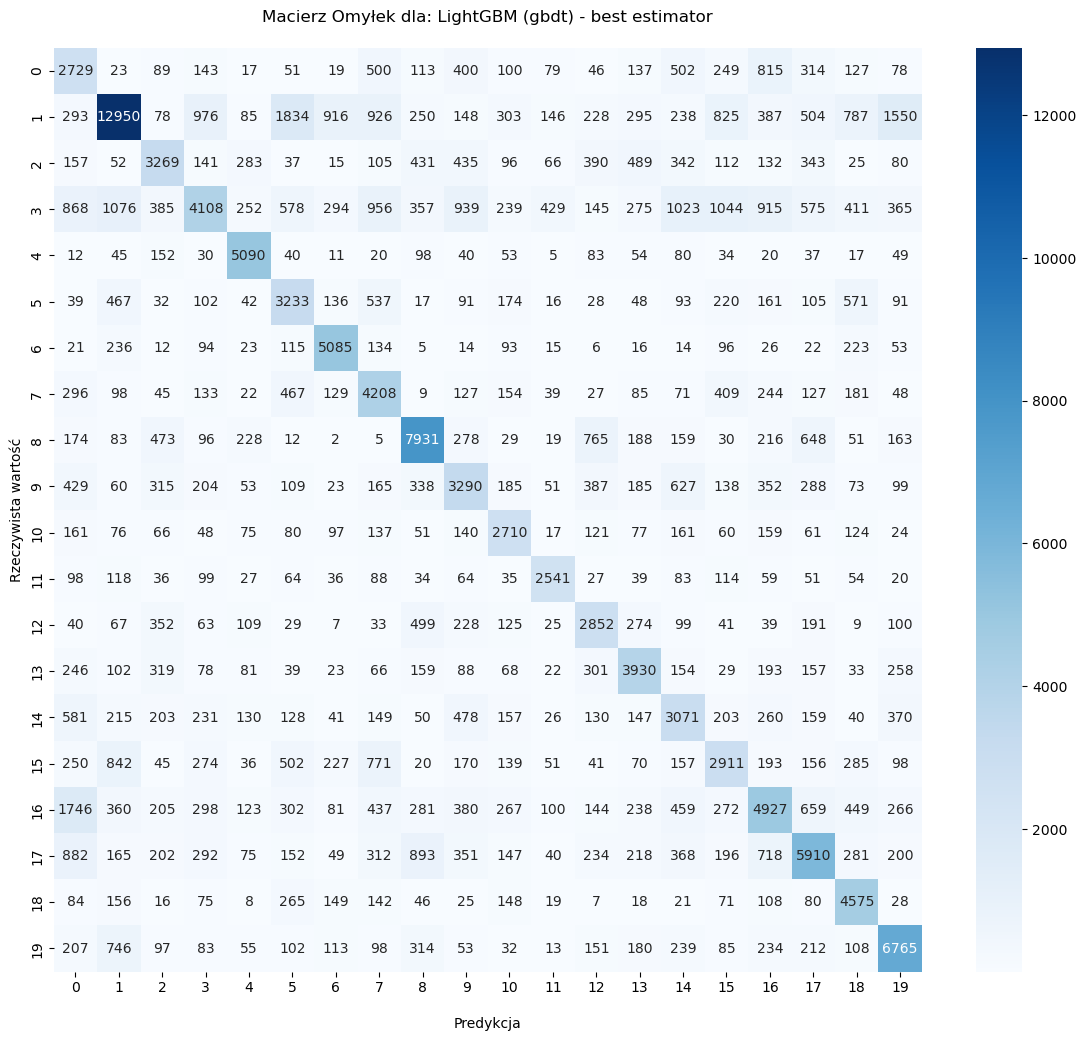


--- Wizualizacje Granic Decyzyjnych ---

[Wizualizacja 1/3] Granica decyzyjna na danych treningowych...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 680293, number of used features: 2
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 2 dense feature groups (2.60 MB) transferred to GPU in 0.001501 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -3.259746
[LightGBM] [Info] Start training from score -1.969932
[LightGBM] [Info] Start training from score -3.190319
[LightGBM] [Info] Start training from score -2.412683
[LightGBM] [Info] Start training from score -3.349524
[LightGBM] [Info] Start training from s

2025/10/11 12:04:52 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 2063c4126bdb49aea14db04acf4b3292. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'colsample_bytree\' was already logged with value=\'0.7\' for run ID=\'2063c4126bdb49aea14db04acf4b3292\'. Attempted logging new value \'0.8\'.")]')]
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


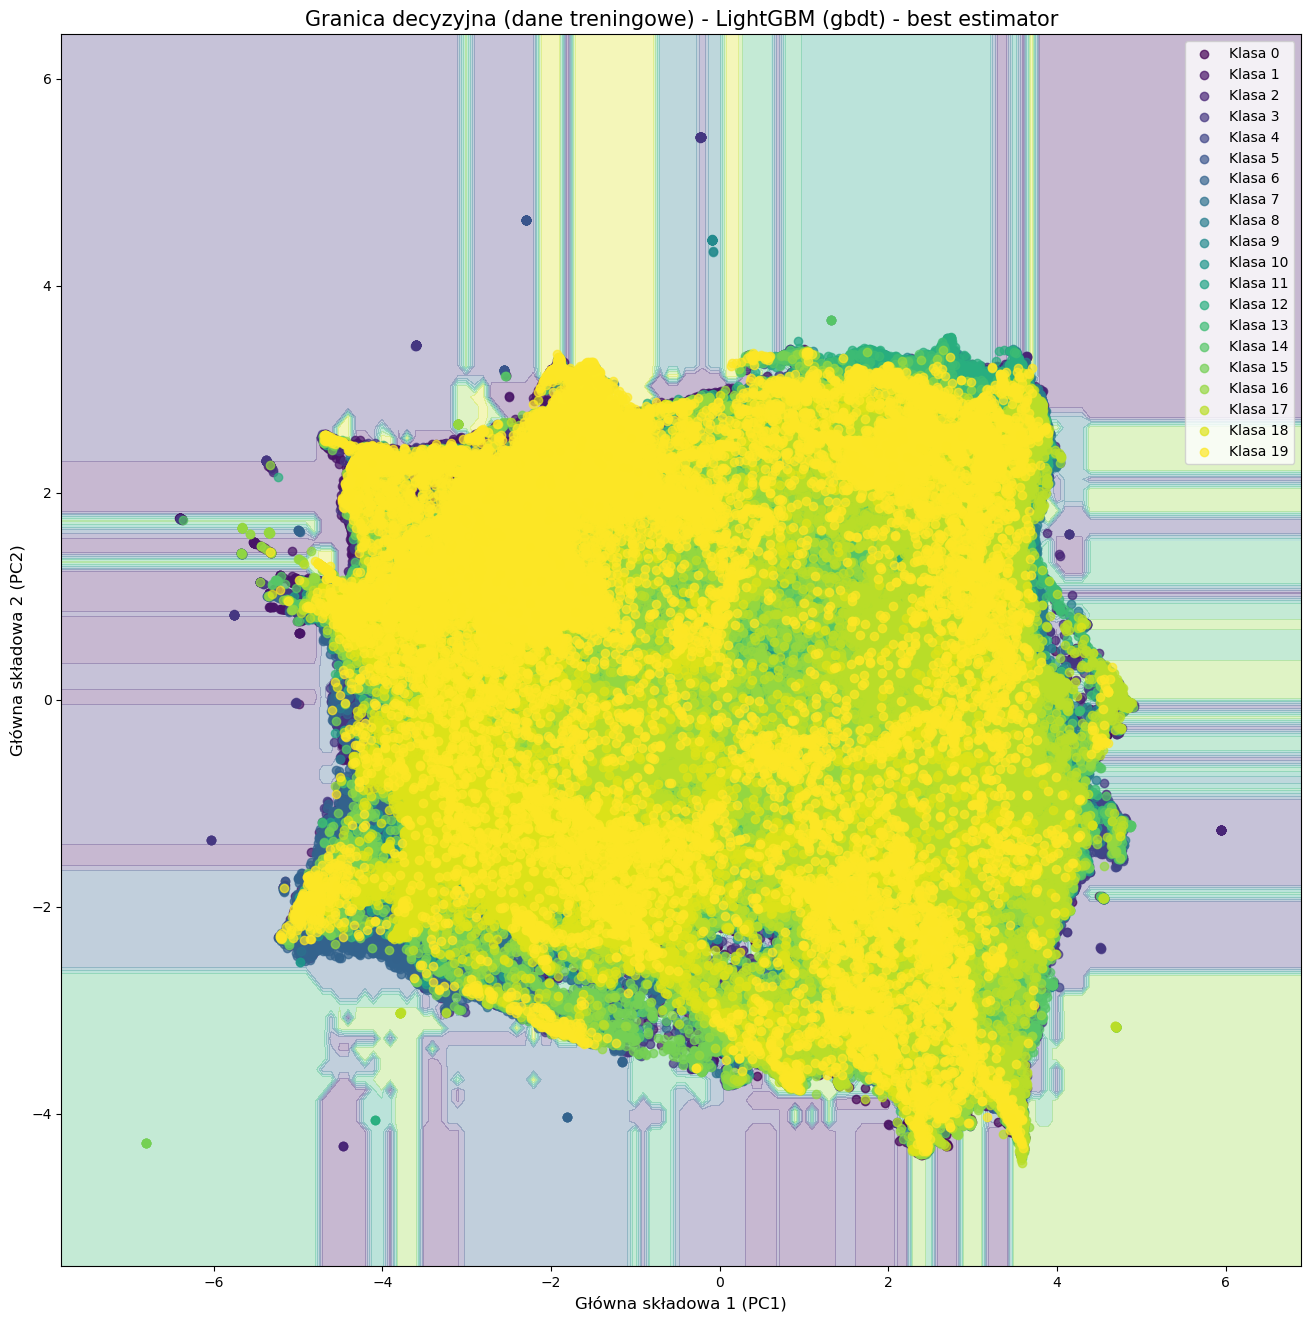


[Wizualizacja 2/3] Granica decyzyjna vs. Rzeczywiste klasy (dane testowe)...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 170074, number of used features: 2
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 2 dense feature groups (0.65 MB) transferred to GPU in 0.000903 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -3.259674
[LightGBM] [Info] Start training from score -1.969957
[LightGBM] [Info] Start training from score -3.190323
[LightGBM] [Info] Start training from score -2.412704
[LightGBM] [Info] Start training from score -3.349487
[LightGBM] [Info] Start training from score -3.311201
[LightGBM] [

2025/10/11 12:09:21 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 2063c4126bdb49aea14db04acf4b3292. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'colsample_bytree\' was already logged with value=\'0.7\' for run ID=\'2063c4126bdb49aea14db04acf4b3292\'. Attempted logging new value \'0.8\'.")]')]
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


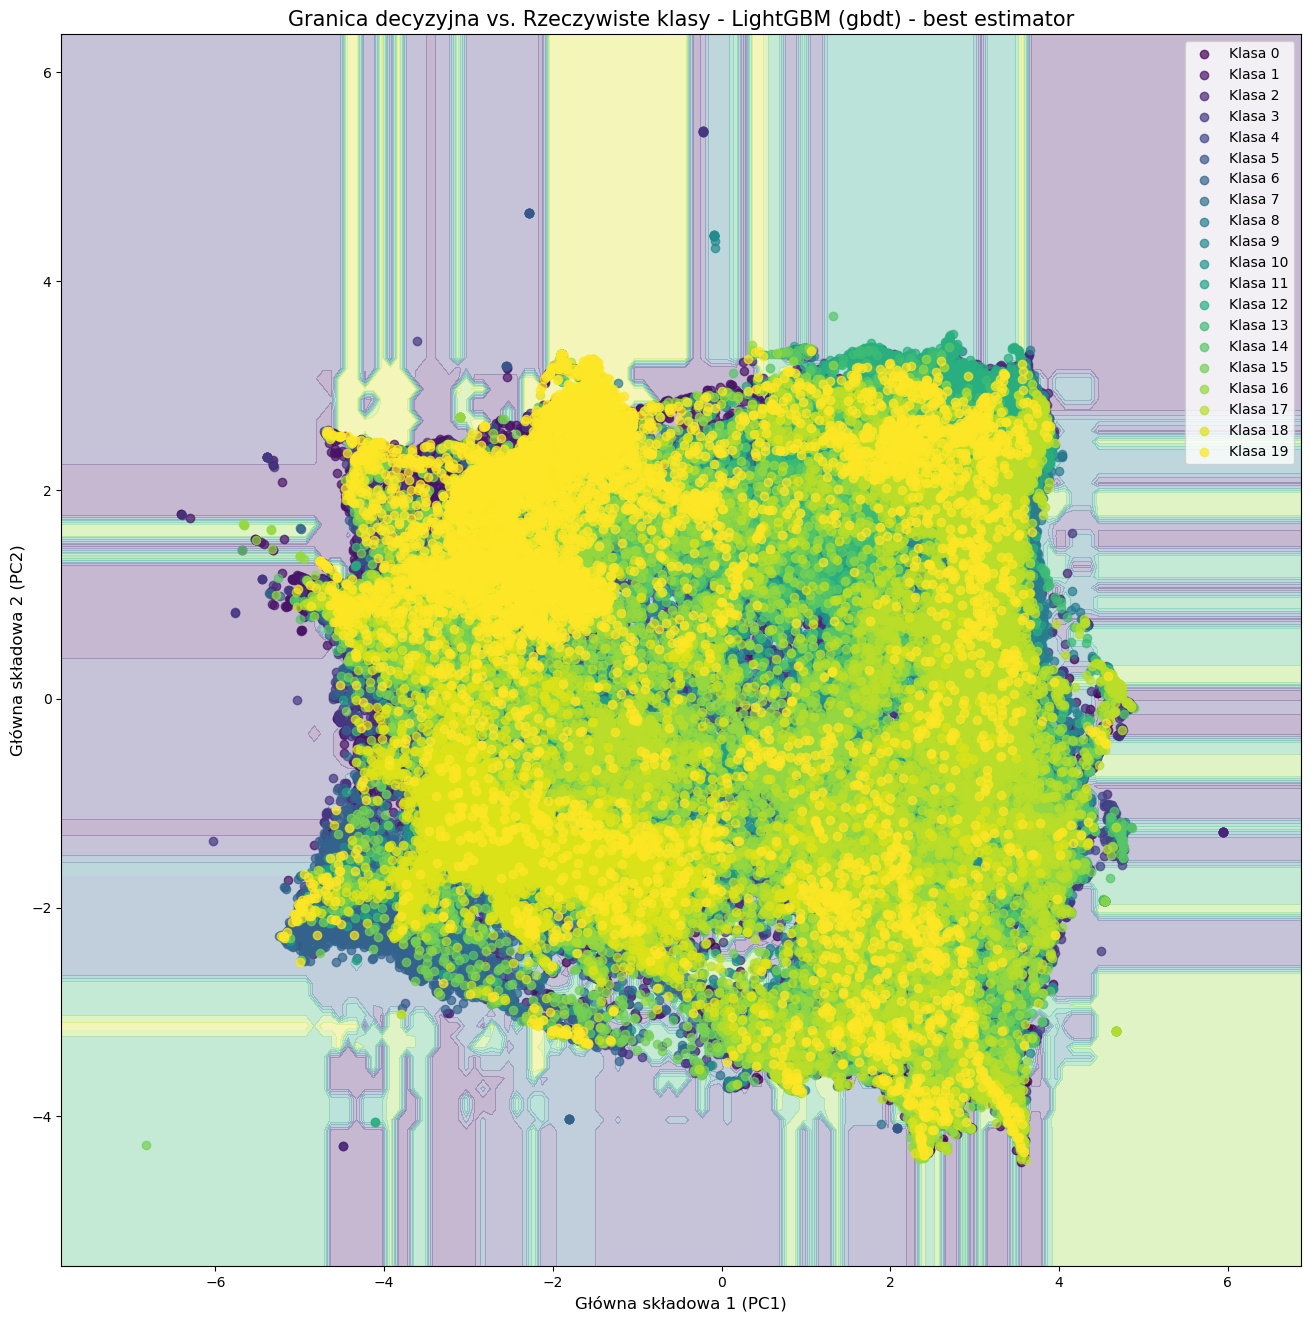


[Wizualizacja 3/3] Granica decyzyjna vs. Predykcje (dane testowe)...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 170074, number of used features: 2
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 2 dense feature groups (0.65 MB) transferred to GPU in 0.000824 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -2.904822
[LightGBM] [Info] Start training from score -2.249368
[LightGBM] [Info] Start training from score -3.281343
[LightGBM] [Info] Start training from score -3.112305
[LightGBM] [Info] Start training from score -3.217254
[LightGBM] [Info] Start training from score -3.039566
[LightGBM] [Info] St

2025/10/11 12:13:49 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 2063c4126bdb49aea14db04acf4b3292. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'colsample_bytree\' was already logged with value=\'0.7\' for run ID=\'2063c4126bdb49aea14db04acf4b3292\'. Attempted logging new value \'0.8\'.")]')]
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


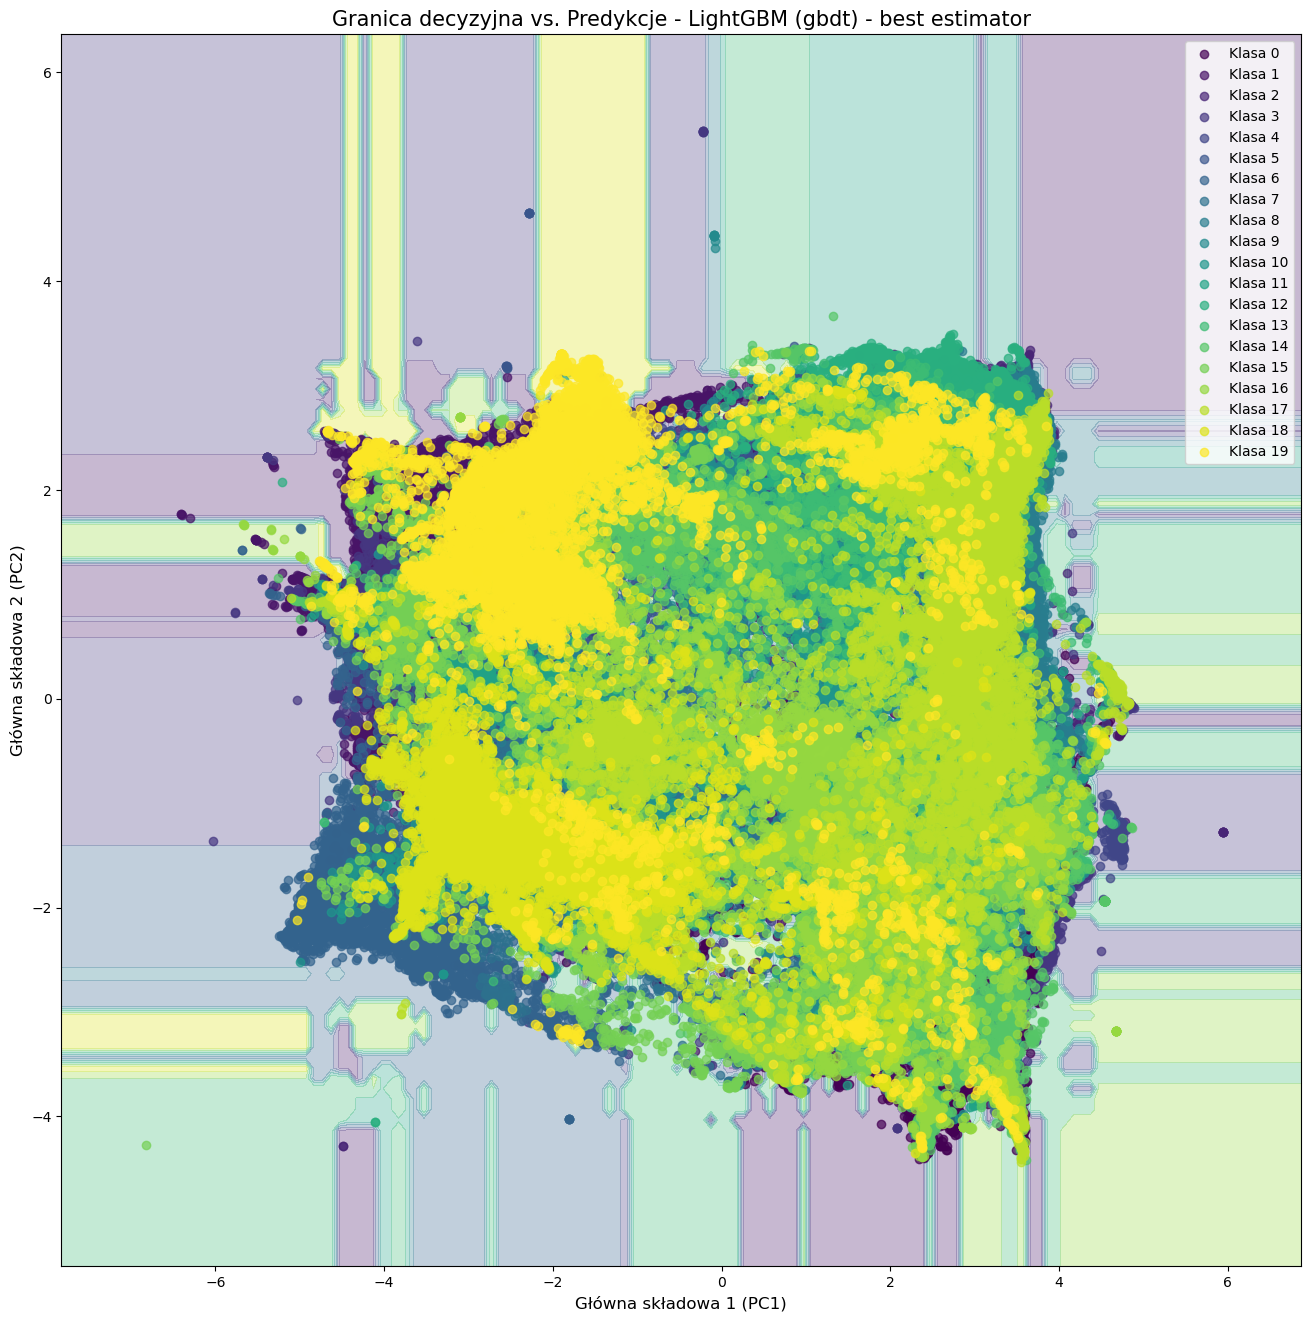


--- Ręczne logowanie najlepszego modelu do MLflow ---


2025/10/11 12:14:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Ręczne logowanie zakończone.

Best hyperparameters: {'subsample': 0.9, 'reg_lambda': 0, 'reg_alpha': 0.5, 'num_leaves': 63, 'n_estimators': 1500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8, 'boosting_type': 'gbdt'}

Podsumowanie Metryk Modeli


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_score_weighted,AUC_weighted
0,XGBoost ver4 - best estimator,0.568247,0.568225,0.568247,0.567310,0.921565
1,XGBoost ver3 - best estimator,0.563678,0.564924,0.563678,0.562784,0.921229
2,LightGBM (gbdt) - best estimator,0.541441,0.553616,0.541441,0.538629,0.925491
3,XGBoost ver2 - best estimator,0.533873,0.545601,0.533873,0.532086,0.919209
4,AdaBoost ver3 - best estimator,0.517504,0.512355,0.517504,0.511639,0.897140
5,AdaBoost ver2 - best estimator,0.515811,0.511166,0.515811,0.509777,0.900985
6,XGBoost - best estimator,0.502775,0.520209,0.502775,0.499303,0.910918
7,Balanced Bagging Classifier - best estimator,0.469895,0.493408,0.469895,0.463513,0.897871
8,Balanced Random Forest ver2 - best estimator,0.467508,0.492287,0.467508,0.461680,0.896450
9,Random Forest - best estimator,0.467696,0.491586,0.467696,0.460895,0.897088


In [6]:
### Model LightGBM - gbdt
import mlflow
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
from sklearn.utils.class_weight import compute_sample_weight

## check and set tracking URI
print("Current tracking URI:", mlflow.get_tracking_uri())
mlflow.set_tracking_uri("file:./mlruns")


#### mlflow.lightgbm.autolog() ##### <- właczamy proces autologowania dla modeli LightGBM
#### przenosimy autolog() do środka bloku 'with'


# rozpoczęcie nowego eksperymentu
mlflow.set_experiment("Covid 19")


# Zakończ aktywny bieg, jeśli istnieje
mlflow.end_run()


### zdefiniowanie modelu
lgb_gbdt = lgb.LGBMClassifier(random_state=42, device='gpu', gpu_platform_id=0, gpu_device_id=0)


#### y_train — wektor etykiet #### funkcja compute_sample_weight automatycznie oblicza wagi odwrotnie proporcjonalne do częstości klas
sample_weights = compute_sample_weight('balanced', y_train)


## siatka hiperparametrów
params_lgb = [
    {
    #### główne parametry
    'boosting_type': ['gbdt'], ##### 'gbdt' to standard, 'dart' może dać lepszą jakość kosztem czasu
    'n_estimators': [1000, 1500],
    'learning_rate': [0.005, 0.01, 0.05],
    
    #### parametry kontrolujące złożoność drzewa (najważniejsze!) 
    'num_leaves': [15, 31, 63],  ### kluczowy parametr
    'max_depth': [-1], ### ogranicza num_leaves. Zwykle -1 (oznacza brak limitu) i kontrola przez num_leaves
    'min_child_samples': [10, 20, 50], ### minimalna liczba próbek w liściu
    
    #### parametry do próbkowania (walka z przeuczeniem) 
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    
    #### parametry regularyzacji (walka z przeuczeniem) 
    'reg_alpha': [0, 0.1, 0.5], ## regularyzacja L1
    'reg_lambda': [0, 0.1, 0.5], ## regularyzacja L2
    }
]



## RandomizedSearchCV zamiast GridSearchCV
lgb_randomsearch = RandomizedSearchCV(
    lgb_gbdt,
    param_distributions=params_lgb,
    n_iter=30,
    scoring='f1_macro',
    cv=5,
    verbose=10,
    n_jobs=1,  #### <--- KLUCZOWA ZMIANA - gdy model działa na GPU, GridSearchCV powinien działać w trybie jednowątkowym (n_jobs=1)
    random_state=42
)


### ręcznie tworzymy przebieg nadrzędny, aby zgrupować wyniki (i dodajemy logowanie)
with mlflow.start_run(run_name="LightGBM-gbdt (Randomized Search)") as parent_run:
    ### pobieramy ID przebiegu nadrzędnego
    parent_run_id = parent_run.info.run_id
    
    ### włączamy autologowanie z dodatkowym tagiem, który połączy przebiegi
    mlflow.lightgbm.autolog(
        log_models=True,
        extra_tags={"mlflow.parentRunId": parent_run_id}
    )
    
    ### trenowanie modelu
    lgb_randomsearch.fit(X_train, y_train, sample_weight=sample_weights)

    ### pobranie najlepszego modelu
    lgb_gbdt_model = lgb_randomsearch.best_estimator_

    ### zapis najlepszego modelu
    joblib.dump(lgb_gbdt_model, 'lgb_gbdt_best_model.joblib')
    print("\nNajlepszy model LightGBM-gbdt został zapisany.")

    ### ewaluacja (pełna ocena modelu) żeby mieć metryki do ręcznego zapisania
    ####### wywołujemy ją wewnątrz bloku 'with', aby mieć dostęp do metryk
    evaluator.evaluate(lgb_gbdt_model, 'LightGBM (gbdt) - best estimator', X_train, y_train, X_test, y_test)
        
    print("\n--- Ręczne logowanie najlepszego modelu do MLflow ---")

    ## 1. Logowanie najlepszych hiperparametrów
    ### prefix 'best_', aby odróżnić je od parametrów z autologowania
    best_params_for_logging = {f"best_{key}": val for key, val in lgb_randomsearch.best_params_.items()}
    mlflow.log_params(best_params_for_logging)

    ## 2. Logowanie końcowych metryk z naszego evaluatora
    ### pobieramy ostatni wiersz z tabeli metryk
    final_metrics = evaluator.metrics_summary.iloc[-1].to_dict()
    del final_metrics['Model'] ##### usuwamy nazwę modelu, bo to nie metryka
    mlflow.log_metrics(final_metrics)

    ## 3. Logowanie samego obiektu modelu
    ### zapisujemy go w osobnym podfolderze 'best_model_manual', aby nie kolidował z autologiem
    mlflow.lightgbm.log_model(
        lgb_model=lgb_gbdt_model,
        artifact_path="best_model_manual"
    )
    print("Ręczne logowanie zakończone.")
    

    ### Wyświetlenie najlepszych hiperparametrów
    print('\nBest hyperparameters:', lgb_randomsearch.best_params_)

    evaluator.display_summary()


In [18]:
### zapis / aktualizacja ewaluatora
joblib.dump(evaluator, 'evaluator.joblib')

print(f"Obiekt ewaluatora został zapisany w pliku evaluator.joblib")

Obiekt ewaluatora został zapisany w pliku evaluator.joblib


In [9]:
### wczytaj wcześniej zapisany obiekt evaluator
evaluator = joblib.load('evaluator.joblib')
print(f"Obiekt ewaluatora został wczytany")

Obiekt ewaluatora został wczytany


Current tracking URI: file:///O:/Projects/covid19/mlruns
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5; 1/8] START boosting_type=gbdt, colsample_bytree=0.8, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=2000, num_leaves=95, reg_alpha=0, reg_lambda=0, subsample=0.8
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 544234, number of used features: 10
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (6.23 MB) transferred to GPU in 0.004342 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -2.995761
[LightGBM] [Info] Start training from score -2.

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV 1/5; 1/8] END boosting_type=gbdt, colsample_bytree=0.8, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=2000, num_leaves=95, reg_alpha=0, reg_lambda=0, subsample=0.8;, score=0.559 total time=10.2min
[CV 2/5; 1/8] START boosting_type=gbdt, colsample_bytree=0.8, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=2000, num_leaves=95, reg_alpha=0, reg_lambda=0, subsample=0.8
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 544234, number of used features: 10
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (6.23 MB) transferred to GPU in 0.003878 secs. 0 sparse feature g

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV 2/5; 1/8] END boosting_type=gbdt, colsample_bytree=0.8, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=2000, num_leaves=95, reg_alpha=0, reg_lambda=0, subsample=0.8;, score=0.555 total time= 9.9min
[CV 3/5; 1/8] START boosting_type=gbdt, colsample_bytree=0.8, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=2000, num_leaves=95, reg_alpha=0, reg_lambda=0, subsample=0.8
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 544234, number of used features: 10
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (6.23 MB) transferred to GPU in 0.003965 secs. 0 sparse feature g

...

[CV 5/5; 8/8] END boosting_type=gbdt, colsample_bytree=0.8, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=2000, num_leaves=95, reg_alpha=0.5, reg_lambda=0.5, subsample=0.9;, score=0.553 total time=10.2min
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 680293, number of used features: 10
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (7.79 MB) transferred to GPU in 0.004561 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Sta

2025/10/12 11:50:29 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 1f4394c5d4d0449daab18cbe73078e27. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'subsample\' was already logged with value=\'0.8\' for run ID=\'1f4394c5d4d0449daab18cbe73078e27\'. Attempted logging new value \'0.9\'.")]')]
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Najlepszy model LightGBM-gbdt ver2 został zapisany.
Ocena modelu: LightGBM (gbdt) ver2 - best estimator


O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Raport Klasyfikacji ---
              precision    recall  f1-score   support

           0       0.32      0.43      0.36      6531
           1       0.71      0.57      0.63     23719
           2       0.53      0.49      0.51      7000
           3       0.54      0.31      0.39     15234
           4       0.76      0.84      0.80      5970
           5       0.43      0.53      0.47      6203
           6       0.70      0.81      0.75      6303
           7       0.45      0.62      0.52      6919
           8       0.68      0.70      0.69     11550
           9       0.45      0.47      0.46      7371
          10       0.55      0.60      0.58      4445
          11       0.71      0.69      0.70      3687
          12       0.49      0.54      0.51      5182
          13       0.58      0.63      0.60      6346
          14       0.40      0.46      0.43      6769
          15       0.44      0.43      0.43      7238
          16       0.49      0.44      0.46     11994

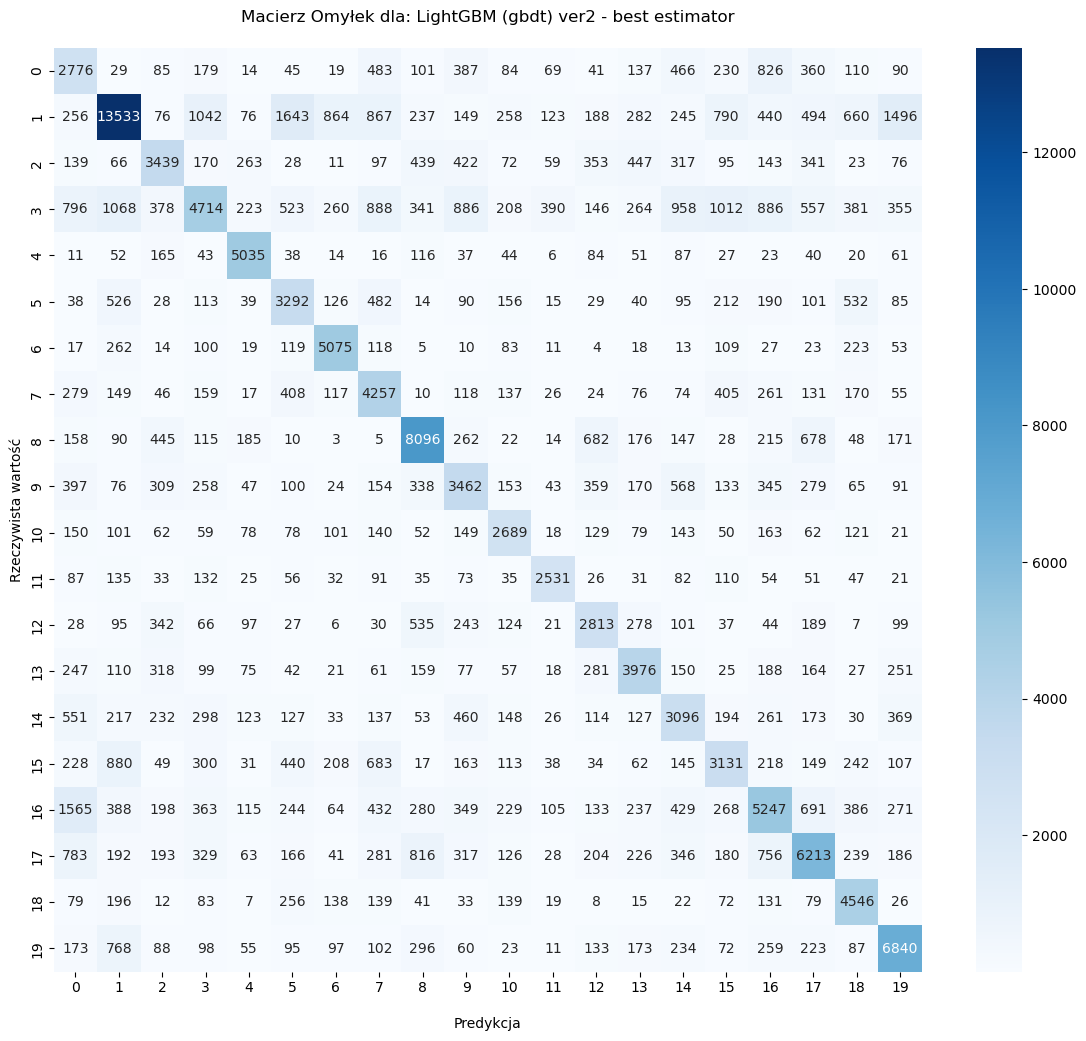


--- Wizualizacje Granic Decyzyjnych ---

[Wizualizacja 1/3] Granica decyzyjna na danych treningowych...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 680293, number of used features: 2
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 2 dense feature groups (2.60 MB) transferred to GPU in 0.001398 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -3.259746
[LightGBM] [Info] Start training from score -1.969932
[LightGBM] [Info] Start training from score -3.190319
[LightGBM] [Info] Start training from score -2.412683
[LightGBM] [Info] Start training from score -3.349524
[LightGBM] [Info] Start training from s

2025/10/12 12:01:11 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 1f4394c5d4d0449daab18cbe73078e27. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'subsample\' was already logged with value=\'0.8\' for run ID=\'1f4394c5d4d0449daab18cbe73078e27\'. Attempted logging new value \'0.9\'.")]')]
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


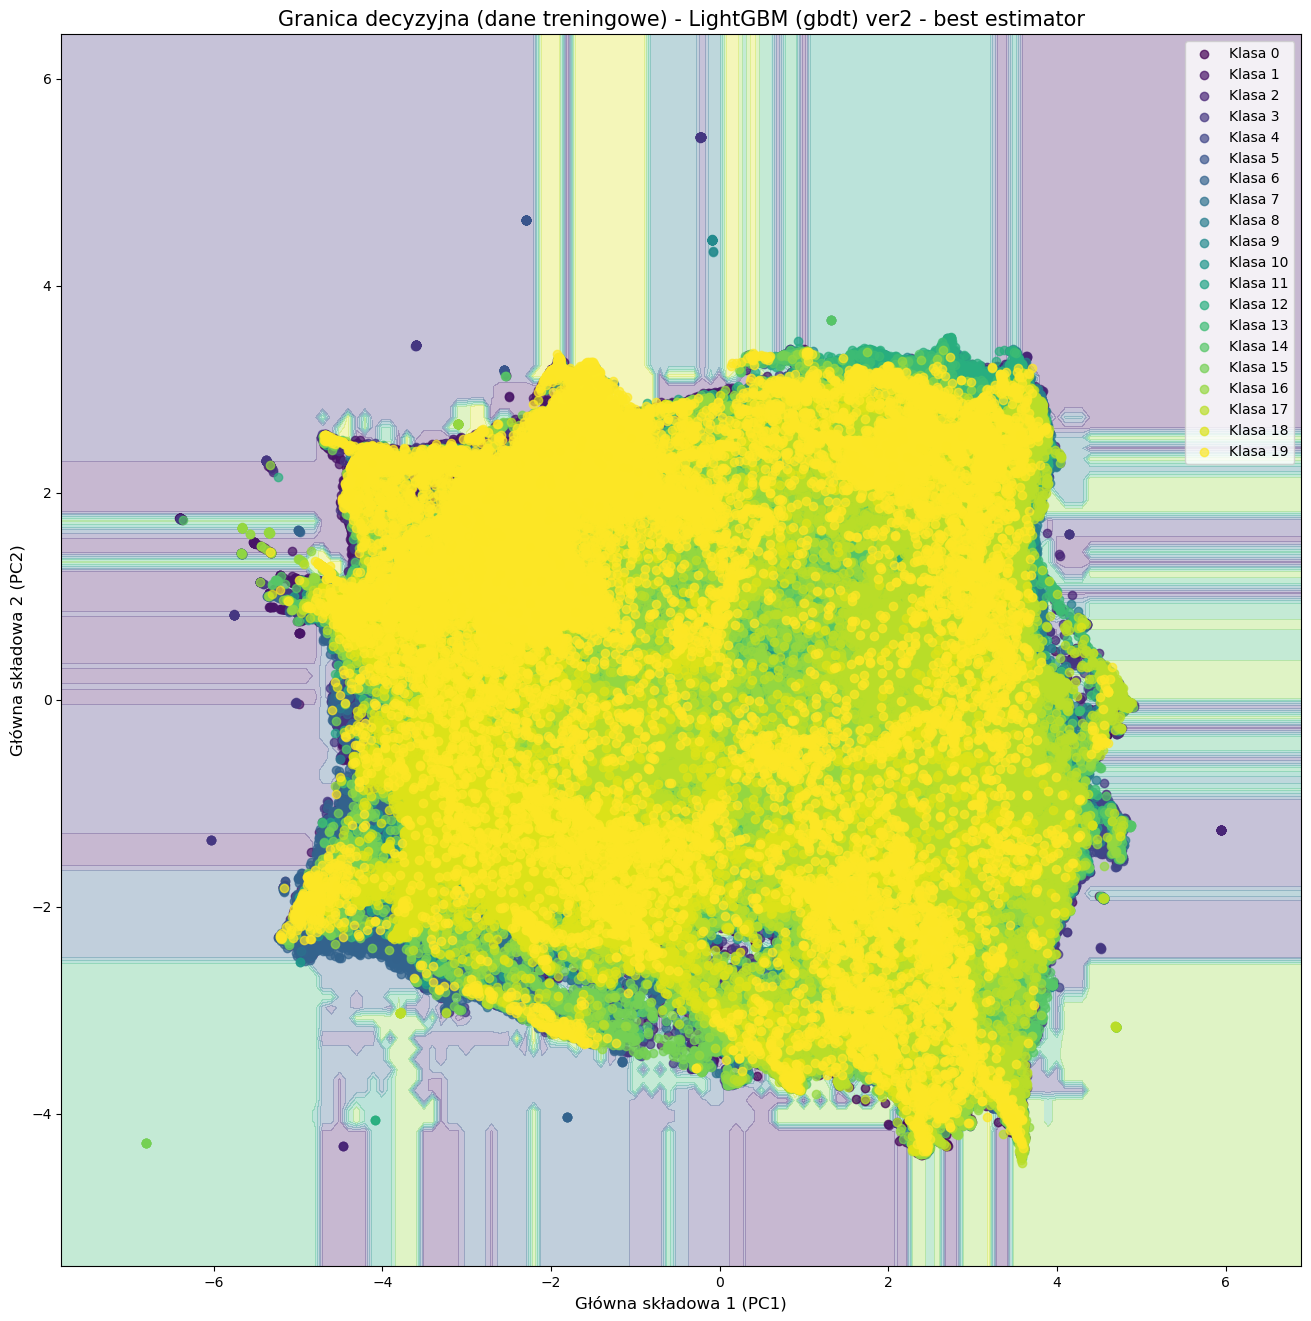


[Wizualizacja 2/3] Granica decyzyjna vs. Rzeczywiste klasy (dane testowe)...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 170074, number of used features: 2
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 2 dense feature groups (0.65 MB) transferred to GPU in 0.001113 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -3.259674
[LightGBM] [Info] Start training from score -1.969957
[LightGBM] [Info] Start training from score -3.190323
[LightGBM] [Info] Start training from score -2.412704
[LightGBM] [Info] Start training from score -3.349487
[LightGBM] [Info] Start training from score -3.311201
[LightGBM] [

2025/10/12 12:09:40 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 1f4394c5d4d0449daab18cbe73078e27. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'subsample\' was already logged with value=\'0.8\' for run ID=\'1f4394c5d4d0449daab18cbe73078e27\'. Attempted logging new value \'0.9\'.")]')]
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


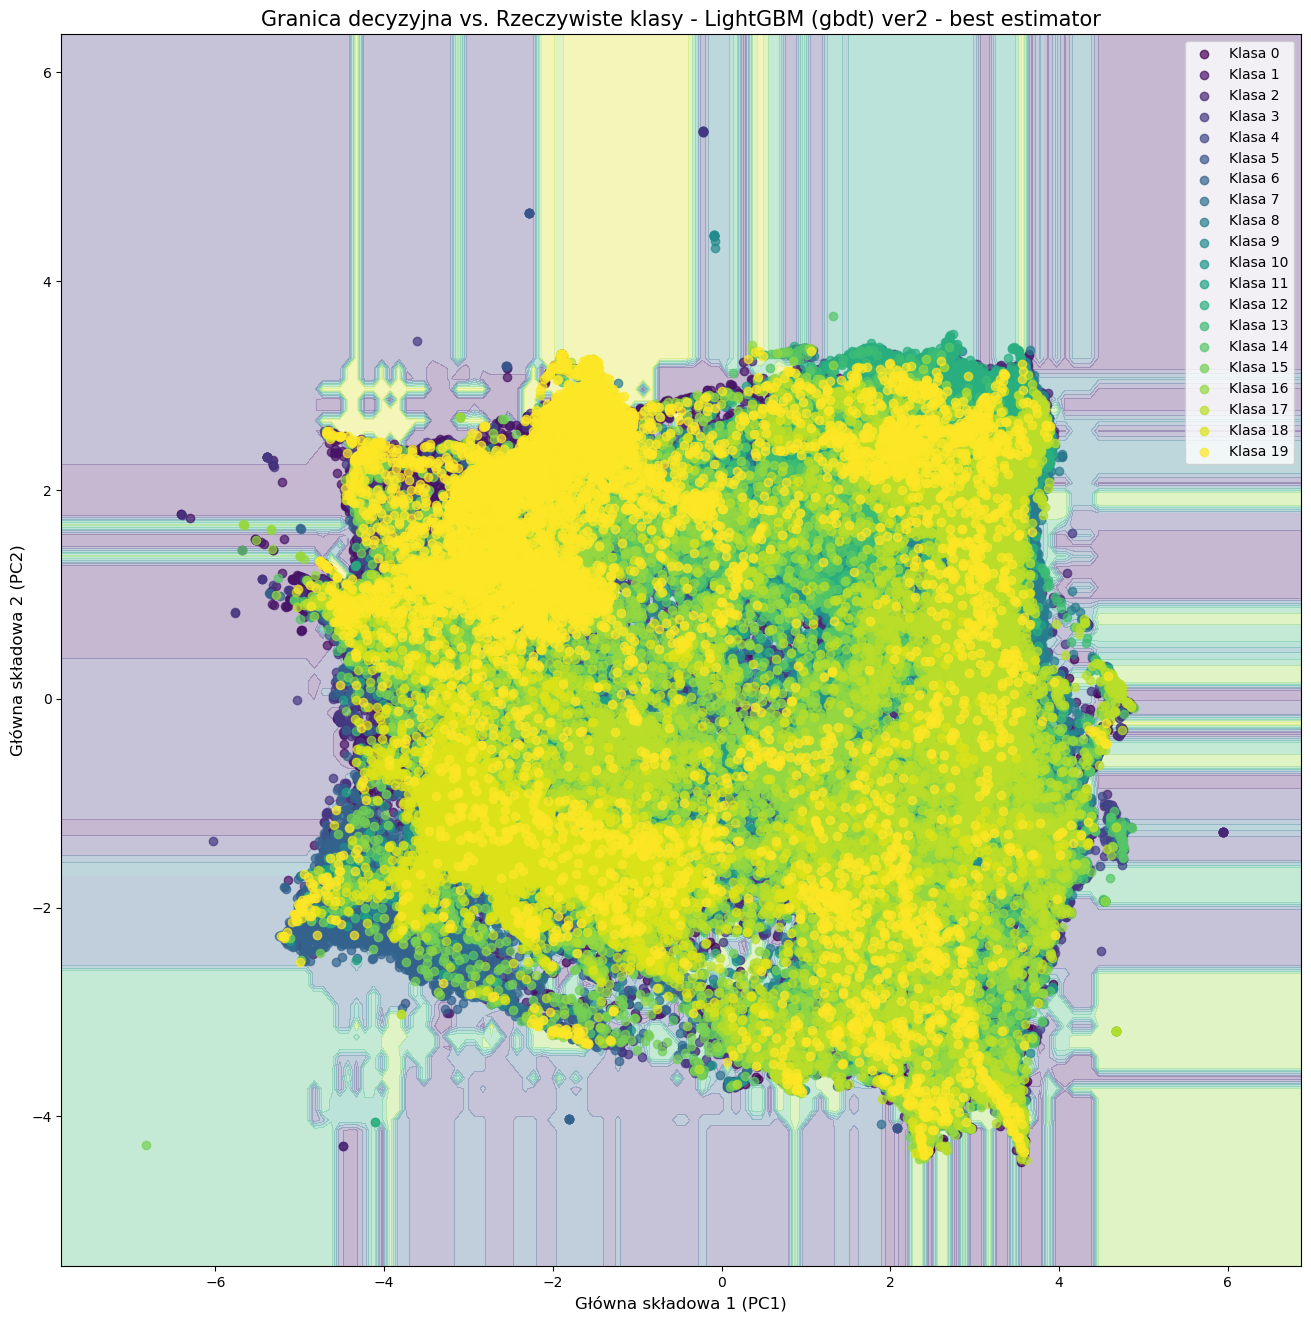


[Wizualizacja 3/3] Granica decyzyjna vs. Predykcje (dane testowe)...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 170074, number of used features: 2
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 2 dense feature groups (0.65 MB) transferred to GPU in 0.001073 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -2.966266
[LightGBM] [Info] Start training from score -2.195327
[LightGBM] [Info] Start training from score -3.262587
[LightGBM] [Info] Start training from score -2.970614
[LightGBM] [Info] Start training from score -3.251136
[LightGBM] [Info] Start training from score -3.090220
[LightGBM] [Info] St

2025/10/12 12:18:14 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 1f4394c5d4d0449daab18cbe73078e27. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'subsample\' was already logged with value=\'0.8\' for run ID=\'1f4394c5d4d0449daab18cbe73078e27\'. Attempted logging new value \'0.9\'.")]')]
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


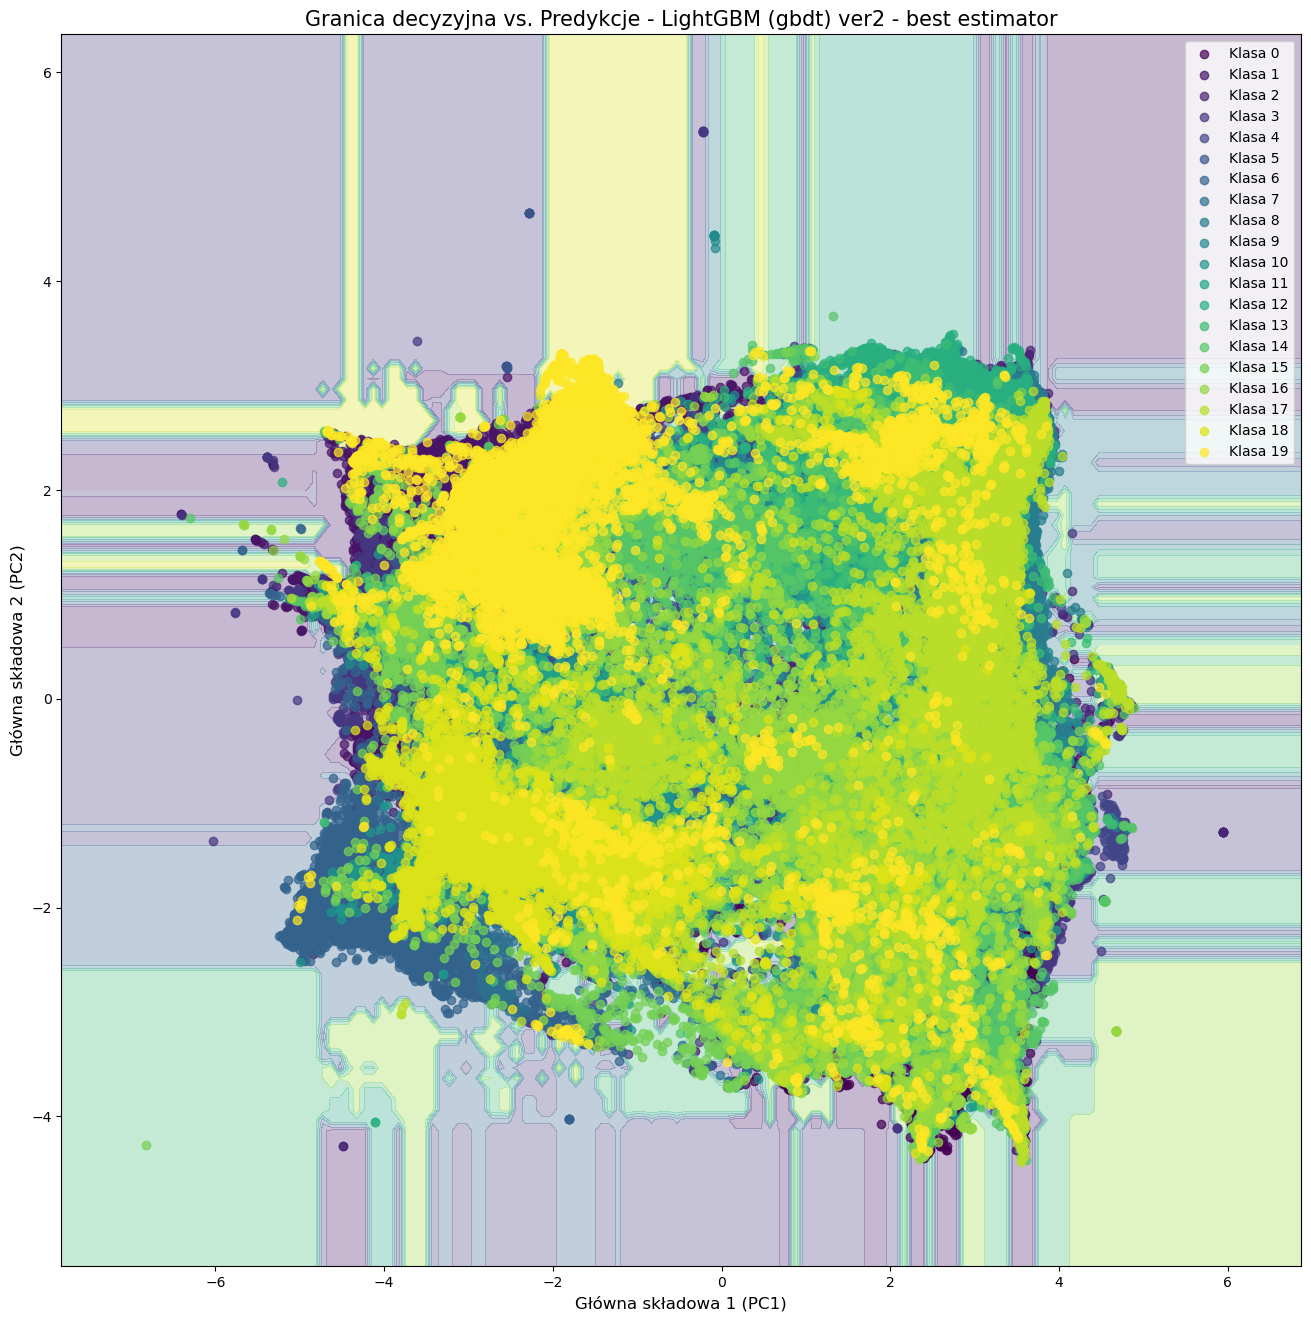


--- Ręczne logowanie najlepszego modelu do MLflow ---


2025/10/12 12:18:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Ręczne logowanie zakończone.

Best hyperparameters: {'boosting_type': 'gbdt', 'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 2000, 'num_leaves': 95, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.9}

Podsumowanie Metryk Modeli


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_score_weighted,AUC_weighted
0,XGBoost ver4 - best estimator,0.568247,0.568225,0.568247,0.567310,0.921565
1,XGBoost ver3 - best estimator,0.563678,0.564924,0.563678,0.562784,0.921229
2,LightGBM (gbdt) ver2 - best estimator,0.557175,0.565336,0.557175,0.555168,0.928085
3,LightGBM (gbdt) - best estimator,0.541441,0.553616,0.541441,0.538629,0.925491
4,XGBoost ver2 - best estimator,0.533873,0.545601,0.533873,0.532086,0.919209
5,AdaBoost ver3 - best estimator,0.517504,0.512355,0.517504,0.511639,0.897140
6,AdaBoost ver2 - best estimator,0.515811,0.511166,0.515811,0.509777,0.900985
7,XGBoost - best estimator,0.502775,0.520209,0.502775,0.499303,0.910918
8,Balanced Bagging Classifier - best estimator,0.469895,0.493408,0.469895,0.463513,0.897871
9,Balanced Random Forest ver2 - best estimator,0.467508,0.492287,0.467508,0.461680,0.896450


In [11]:
### Model LightGBM - gbdt ver2
import mlflow
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
from sklearn.utils.class_weight import compute_sample_weight

## check and set tracking URI
print("Current tracking URI:", mlflow.get_tracking_uri())
mlflow.set_tracking_uri("file:./mlruns")


#### mlflow.lightgbm.autolog() ##### <- właczamy proces autologowania dla modeli LightGBM
#### przenosimy autolog() do środka bloku 'with'


# rozpoczęcie nowego eksperymentu
mlflow.set_experiment("Covid 19")


# Zakończ aktywny bieg, jeśli istnieje
mlflow.end_run()


### zdefiniowanie modelu
lgb_gbdt_ver2 = lgb.LGBMClassifier(random_state=42, device='gpu', gpu_platform_id=0, gpu_device_id=0)


#### y_train — wektor etykiet #### funkcja compute_sample_weight automatycznie oblicza wagi odwrotnie proporcjonalne do częstości klas
sample_weights = compute_sample_weight('balanced', y_train)


## siatka hiperparametrów 
params_lgb_gbdt_ver2 = [
    {
    'boosting_type': ['gbdt'],
    'n_estimators': [2000],
    'learning_rate': [0.05],
    'num_leaves': [95],
    'max_depth': [-1],
    'min_child_samples': [20],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8],
    'reg_alpha': [0, 0.5], ## regularyzacja L1
    'reg_lambda': [0, 0.5], ## regularyzacja L2
    }
]


## GridSearchCV
lgb_gbdt_ver2_gridsearch = GridSearchCV(
    lgb_gbdt_ver2,
    param_grid=params_lgb_gbdt_ver2,
    scoring='f1_macro',
    cv=5,
    verbose=10,
    n_jobs=1,  #### <--- KLUCZOWA ZMIANA - gdy model działa na GPU, GridSearchCV powinien działać w trybie jednowątkowym (n_jobs=1)
)


### ręcznie tworzymy przebieg nadrzędny, aby zgrupować wyniki (i dodajemy logowanie)
with mlflow.start_run(run_name="LightGBM-gbdt ver2 (Grid Search)") as parent_run:
    ### pobieramy ID przebiegu nadrzędnego
    parent_run_id = parent_run.info.run_id
    
    ### włączamy autologowanie z dodatkowym tagiem, który połączy przebiegi
    mlflow.lightgbm.autolog(
        log_models=True,
        extra_tags={"mlflow.parentRunId": parent_run_id}
    )
    
    ### trenowanie modelu
    lgb_gbdt_ver2_gridsearch.fit(X_train, y_train, sample_weight=sample_weights)

    ### pobranie najlepszego modelu
    lgb_gbdt_ver2_model = lgb_gbdt_ver2_gridsearch.best_estimator_

    ### zapis najlepszego modelu
    joblib.dump(lgb_gbdt_ver2_model, 'lgb_gbdt_best_model_ver2.joblib')
    print("\nNajlepszy model LightGBM-gbdt ver2 został zapisany.")

    ### ewaluacja (pełna ocena modelu) żeby mieć metryki do ręcznego zapisania
    ####### wywołujemy ją wewnątrz bloku 'with', aby mieć dostęp do metryk
    evaluator.evaluate(lgb_gbdt_ver2_model, 'LightGBM (gbdt) ver2 - best estimator', X_train, y_train, X_test, y_test)
        
    print("\n--- Ręczne logowanie najlepszego modelu do MLflow ---")

    ## 1. Logowanie najlepszych hiperparametrów
    ### prefix 'best_', aby odróżnić je od parametrów z autologowania
    best_params_for_logging = {f"best_{key}": val for key, val in lgb_gbdt_ver2_gridsearch.best_params_.items()}
    mlflow.log_params(best_params_for_logging)

    ## 2. Logowanie końcowych metryk z naszego evaluatora
    ### pobieramy ostatni wiersz z tabeli metryk
    final_metrics = evaluator.metrics_summary.iloc[-1].to_dict()
    del final_metrics['Model'] ##### usuwamy nazwę modelu, bo to nie metryka
    mlflow.log_metrics(final_metrics)

    ## 3. Logowanie samego obiektu modelu
    ### zapisujemy go w osobnym podfolderze 'best_model_manual', aby nie kolidował z autologiem
    mlflow.lightgbm.log_model(
        lgb_model=lgb_gbdt_ver2_model,
        artifact_path="best_model_manual"
    )
    print("Ręczne logowanie zakończone.")
    

    ### Wyświetlenie najlepszych hiperparametrów
    print('\nBest hyperparameters:', lgb_gbdt_ver2_gridsearch.best_params_)

    evaluator.display_summary()


In [13]:
### zapis / aktualizacja ewaluatora
joblib.dump(evaluator, 'evaluator.joblib')

print(f"Obiekt ewaluatora został zapisany w pliku evaluator.joblib")

Obiekt ewaluatora został zapisany w pliku evaluator.joblib
